In [77]:
"""
Проект «Реальность потребительской корзины»
Цель: Предсказание отклонения от официальных значений (difference) по параметрам:
- пол
- возраст
- доход
- город
- стиль жизни

Шаги:
1. Загрузка данных из Excel
2. Первичный анализ и переименование столбцов (если требуется)
3. Генерация синтетических данных (бутстрэппинг с добавлением шума)
4. Формирование итогового датасета с выбранными признаками
5. Кодирование категориальных признаков
6. Масштабирование, разделение выборки, обучение модели линейной регрессии
7. Тестирование модели
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------
# 1. Загрузка и первичный анализ данных
# ------------------------------

# Замените путь к файлу, если он находится в другой папке
data_file = "set.xlsx"  # замените на имя вашего файла

try:
    df = pd.read_excel(data_file)
except Exception as e:
    print("Ошибка загрузки файла: ", e)
    exit(1)

print("Первые 5 строк загруженных данных:")
print(df.head())

Первые 5 строк загруженных данных:
           ID  sex  age lifestyle  salary                          city  \
0  1995902821  Жен   20    active   60000                        Москва   
1  1996067555  Муж   35    medium   30000                        Москва   
2  1996071674  Муж   20    active  150000                        Москва   
3  1996073501  Муж   20    active   60000  Саратов, Саратовская область   
4  1996076712  Муж   20    active  100000                        Москва   

   official_difference  
0          4739.450000  
1          4678.850000  
2          5101.750000  
3          3828.346154  
4          5253.450000  


In [79]:
# ------------------------------
# 3. Генерация синтетических данных (бутстрэппинг с добавлением шума)
# ------------------------------

def generate_synthetic_bootstrap(data, n_samples, noise_factor=0.05, random_state=42):
    np.random.seed(random_state)
    synthetic_samples = []
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    for _ in range(n_samples):
        sample = data.sample(n=1, replace=True).iloc[0].copy()
        for col in numeric_columns:
            std_dev = data[col].std()
            if pd.isna(std_dev) or std_dev == 0:
                continue
            noise = np.random.normal(loc=0, scale=noise_factor * std_dev)
            sample[col] = sample[col] + noise
        synthetic_samples.append(sample)
    synthetic_df = pd.DataFrame(synthetic_samples)
    return synthetic_df

# Для увеличения данных задаем коэффициент, например, в 3 раза больше исходных наблюдений:
n_original = df.shape[0]
n_synthetic = n_original * 10
synthetic_df = generate_synthetic_bootstrap(df, n_samples=n_synthetic, noise_factor=0.05)
print("\nПервые 5 строк синтетических данных:")
print(synthetic_df.head())

# Объединяем исходные и синтетические данные
extended_df = pd.concat([df, synthetic_df], ignore_index=True)
print("\nРазмер объединенного датасета:", extended_df.shape)



Первые 5 строк синтетических данных:
              id  sex        age lifestyle         salary  \
38  2.009508e+09  Жен  20.190284    active   13663.589310   
18  1.996169e+09  Муж  26.657102    medium  176892.210466   
2   1.996020e+09  Муж  20.200299    active  148373.073559   
11  1.996124e+09  Муж  19.842070    medium  248132.941794   
15  1.996118e+09  Жен  19.939505    active   15817.030402   

                                  city  official_difference  
38  Новосибирск, Новосибирская область          4022.471944  
18                              Москва          4628.418649  
2                               Москва          5088.381814  
11                              Москва          4947.478014  
15                              Москва          4588.831915  

Размер объединенного датасета: (429, 7)


In [80]:
# ------------------------------
# 4. Формирование итогового датасета с выбранными признаками
# ------------------------------
# Выбираем только нужные признаки: пол, возраст, доход, город, стиль жизни, и целевую переменную official_difference
required_columns = ['sex', 'age', 'salary', 'city', 'lifestyle', 'official_difference']

# Проверим, все ли нужные столбцы присутствуют
for col in required_columns:
    if col not in extended_df.columns:
        print(f"Ошибка: столбец {col} отсутствует в данных!")
        exit(1)

data_model = extended_df[required_columns].copy()
print("\nПервые строки итогового датасета для модели:")
print(data_model.head())



Первые строки итогового датасета для модели:
   sex   age    salary                          city lifestyle  \
0  Жен  20.0   60000.0                        Москва    active   
1  Муж  35.0   30000.0                        Москва    medium   
2  Муж  20.0  150000.0                        Москва    active   
3  Муж  20.0   60000.0  Саратов, Саратовская область    active   
4  Муж  20.0  100000.0                        Москва    active   

   official_difference  
0          4739.450000  
1          4678.850000  
2          5101.750000  
3          3828.346154  
4          5253.450000  


In [81]:
# ------------------------------
# 5. Кодирование категориальных признаков
# ------------------------------
# Обработка столбца "sex": если значения "муж"/"жен", можно создать бинарное представление
if 'sex' in data_model.columns:
    data_model['sex'] = data_model['sex'].astype(str)
    # Пример: 1 для "муж", 0 для "жен"
    data_model['sex_binary'] = data_model['sex'].apply(lambda x: 1 if x.strip().lower() in ['муж', 'male'] else 0)
    # Убираем исходный столбец, если он больше не нужен:
    data_model = data_model.drop(columns=['sex'])

# Кодируем категориальные переменные: "city" и "lifestyle"
data_model = pd.get_dummies(data_model, columns=['city', 'lifestyle'], drop_first=True)


In [82]:
# ------------------------------
# 6. Подготовка данных для обучения
# ------------------------------

target_column = "official_difference"
if target_column not in data_model.columns:
    print(f"Ошибка: столбец целевой переменной '{target_column}' отсутствует!")
    exit(1)

X = data_model.drop(columns=[target_column])
y = data_model[target_column]

# Разбиваем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
# ------------------------------
# 7. Построение Pipeline и GridSearchCV
# ------------------------------

# Создаем Pipeline: стандартная масштабировка, полиномиальное расширение, Ridge-регрессия
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

# Подбираем оптимальную степень полинома и значение alpha
param_grid = {
    'poly__degree': [2, 3],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\nЛучшая комбинация параметров:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# Оценка на тестовой выборке
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nОценка лучшей модели:\nMSE: {mse:.4f}\nR²: {r2:.4f}")



Лучшая комбинация параметров:
{'poly__degree': 3, 'ridge__alpha': 0.01}

Оценка лучшей модели:
MSE: 9444.6630
R²: 0.9692


In [84]:
# ------------------------------
# 9. Пример использования модели для нового наблюдения
# ------------------------------

# Допустим, у пользователя следующие параметры:
# age: 35, income: 45000, sex: "муж" (=> sex_binary = 1),
# city: "Москва", lifestyle: "активный"
#
# Сначала формируем DataFrame с исходными данными (без dummy-переменных)
input_data = {
    "age": [22],
    "salary": [150000],
    "sex_binary": [1]
}
input_df = pd.DataFrame(input_data)

# Добавляем dummy-признаки для 'city' и 'lifestyle'
# Для этого посмотрим, какие dummy-признаки присутствуют в обучающем наборе
print("\nСписок признаков после кодирования (для dummy-переменных):")
print(X.columns.tolist())

# Пример автоматического заполнения: если в dummy-признаках встречается, например, "city_moskva" или "lifestyle_aktivnyy",
# мы установим значение 1 для нужного класса, а остальные — 0.
dummy_values = {}
for col in X.columns:
    if col.startswith("city_"):
        dummy_values[col] = 1 if "mosk" in col.lower() else 0
    elif col.startswith("lifestyle_"):
        dummy_values[col] = 1 if "aktiv" in col.lower() else 0

# Добавляем dummy-признаки в input_df
for dummy_col, val in dummy_values.items():
    input_df[dummy_col] = val

# Для тех признаков, которые отсутствуют, добавляем их со значением 0
for col in X.columns:
    if col not in input_df.columns:
        input_df[col] = 0

# Переставляем столбцы так, чтобы порядок соответствовал обучающему набору
input_df = input_df[X.columns]

# Масштабируем входные признаки
input_scaled = scaler.transform(input_df)
# Применяем полиномиальное преобразование
input_poly = poly.transform(input_scaled)

# Получаем предсказание
prediction = model_poly.predict(input_poly)
print("\nПрогноз отклонения (official_difference) для заданных параметров:", prediction[0])



Список признаков после кодирования (для dummy-переменных):
['age', 'salary', 'sex_binary', 'city_Екатеринбург, Свердловская область', 'city_Иркутск, Иркутская область', 'city_Москва', 'city_Новосибирск, Новосибирская область', 'city_Санкт-Петербург, Санкт-Петербург и Ленинградская область', 'city_Саратов, Саратовская область', 'city_Смоленск, Смоленская область', 'city_Тула, Тульская область', 'city_Улан-Удэ, Республика Бурятия', 'city_Щёлково, Москва и Московская область', 'city_Ярославль, Ярославская область', 'lifestyle_domestic', 'lifestyle_medium', 'lifestyle_passive']

Прогноз отклонения (official_difference) для заданных параметров: -11389.155406951042


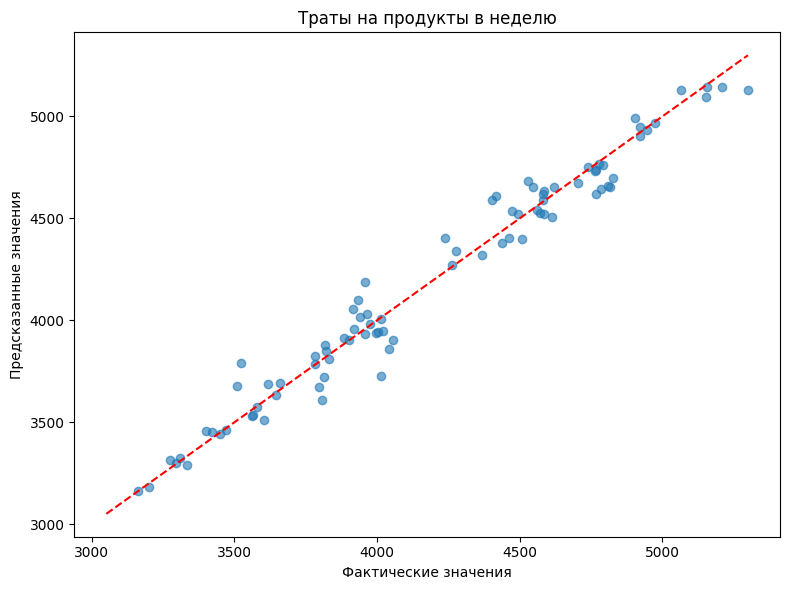

In [ ]:
# ------------------------------
# 9. Визуализация результатов
# ------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Фактические значения delta")
plt.ylabel("Предсказанные значения delta")
plt.title("Сравнение фактических и предсказанных значений (Pipeline с GridSearchCV)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.tight_layout()
plt.show()